# Week 10: K-Means Clustering

## Setup and Data Loading

Importing libraries needed for k-means clustering, including tools for feature scaling, the elbow method, and Silhouette score, and loading the diabetes dataset used throughout this capstone.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

df = pd.read_csv('diabetes_binary_5050split_health_indicators_BRFSS2015.csv')
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


## Feature Scaling

Scaling all features before applying k-means so that no single feature (such as BMI, which ranges much wider than binary 0/1 features) dominates the distance calculations, following the scaling principle from this week's lesson.

In [2]:
X = df.drop('Diabetes_binary', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)
print(X_scaled[:2])

(70692, 21)
[[ 0.88020109 -1.05279808  0.15927581 -0.54217564 -0.95171054 -0.25747348
  -0.41647033  0.64992528 -1.25537143  0.51748481 -0.21125109  0.21717454
  -0.32194493  0.1463042   0.15301974  2.40400793 -0.58155367  1.09004602
  -1.60723742  1.04856175  1.05815996]
 [ 0.88020109  0.94984976  0.15927581 -0.54217564  1.05073965  3.88389516
  -0.41647033 -1.53863842  0.79657699 -1.93242386 -0.21125109  0.21717454
  -0.32194493  0.1463042  -0.46005828 -0.57745057 -0.58155367  1.09004602
   1.19768093  1.04856175  1.05815996]]


## Elbow Method

Testing a range of k values (number of clusters) and plotting WCSS (inertia) against k to look for the "elbow," the point where the drop in WCSS starts to level off, following the elbow method described in this week's lesson.

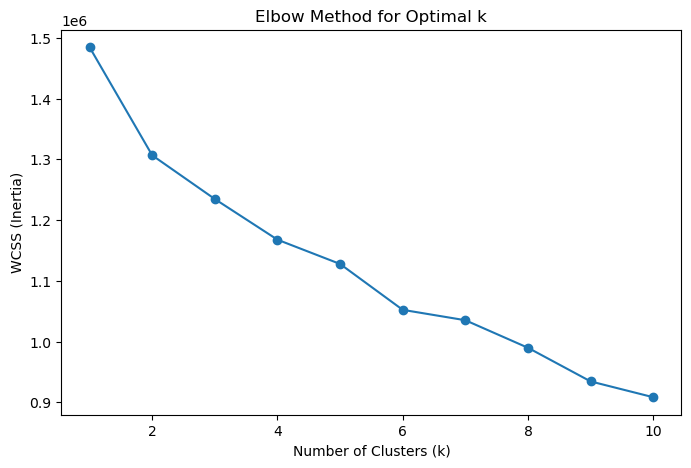

In [4]:
wcss = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')
plt.savefig('week10_elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

## Silhouette Score

Calculating the Silhouette score for a range of k values to get a more precise, quantitative confirmation of the best number of clusters, since the elbow plot did not show a dramatically sharp bend.

k=2: Silhouette score = 0.1633
k=3: Silhouette score = 0.0754
k=4: Silhouette score = 0.0831
k=5: Silhouette score = 0.0815
k=6: Silhouette score = 0.0985
k=7: Silhouette score = 0.0839


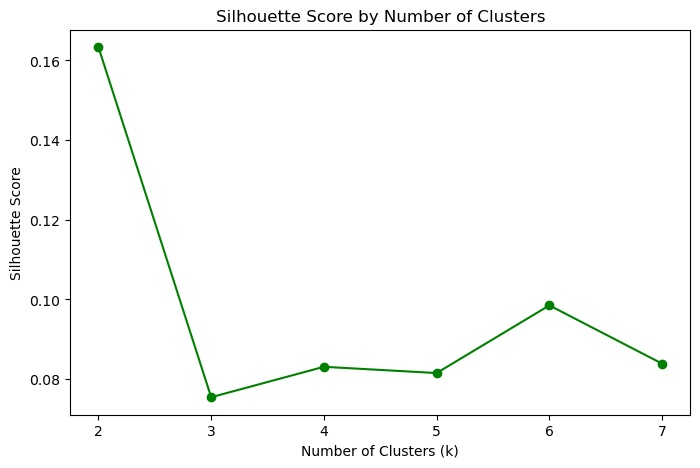

In [5]:
silhouette_scores = []
k_values_sil = range(2, 8)

for k in k_values_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(score)
    print(f"k={k}: Silhouette score = {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(k_values_sil, silhouette_scores, marker='o', color='green')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by Number of Clusters')
plt.savefig('week10_silhouette_scores.png', dpi=300, bbox_inches='tight')
plt.show()

## Final K-Means Model (k=2)

Building the final k-means model using k=2, the value supported by both the elbow method and the Silhouette score, and examining the resulting cluster sizes and characteristics.

In [6]:
final_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_scaled)

df['Cluster'] = cluster_labels

print(df['Cluster'].value_counts())
print()
print(df.groupby('Cluster')[['BMI', 'Age', 'GenHlth', 'HighBP', 'Diabetes_binary']].mean())

Cluster
1    47067
0    23625
Name: count, dtype: int64

               BMI       Age   GenHlth    HighBP  Diabetes_binary
Cluster                                                          
0        32.660825  9.460656  3.832381  0.807365         0.751492
1        28.449614  8.144050  2.337498  0.441031         0.373765


## Visualizing the Clusters

Plotting the two clusters against BMI and General Health, the two features that showed the largest difference between clusters, to visually confirm the separation found by k-means.

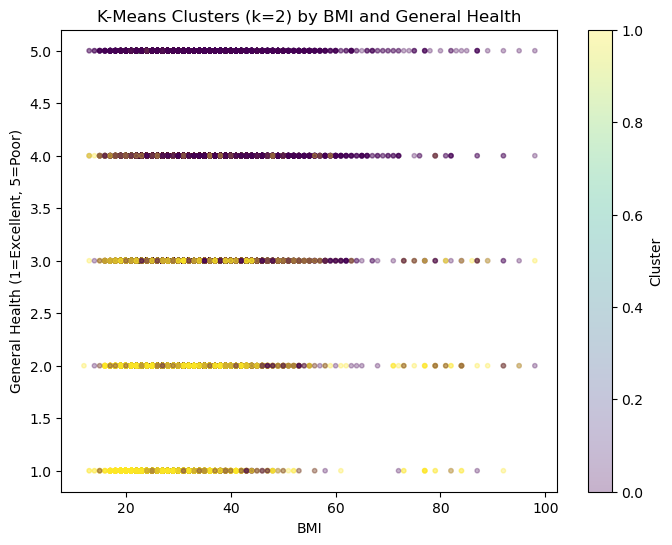

In [7]:
plt.figure(figsize=(8, 6))
plt.scatter(df['BMI'], df['GenHlth'], c=df['Cluster'], cmap='viridis', alpha=0.3, s=10)
plt.xlabel('BMI')
plt.ylabel('General Health (1=Excellent, 5=Poor)')
plt.title('K-Means Clusters (k=2) by BMI and General Health')
plt.colorbar(label='Cluster')
plt.savefig('week10_cluster_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## Note on Cluster Visualization

The two clusters do not appear cleanly separated in this two-feature plot, even though their group averages differed substantially. This is expected: clustering was based on all 21 scaled features simultaneously, so no single pair of features can fully visualize the separation the model actually found. This is a useful limitation to discuss in Milestone Two under "expected vs. unexpected" results.

## Checking Cluster Patterns Across Demographic Subgroups

Testing whether the two clusters found by k-means show consistent patterns across income and education levels, or whether the relationship between cluster membership and diabetes risk differs by subgroup.

In [8]:
print("Diabetes rate by Cluster and Income level:")
print(df.groupby(['Cluster', 'Income'])['Diabetes_binary'].mean().unstack())
print()
print("Diabetes rate by Cluster and Education level:")
print(df.groupby(['Cluster', 'Education'])['Diabetes_binary'].mean().unstack())

Diabetes rate by Cluster and Income level:
Income        1.0       2.0       3.0       4.0       5.0      6.0       7.0  \
Cluster                                                                        
0        0.744316  0.758283  0.760840  0.750909  0.757798  0.74406  0.745882   
1        0.339096  0.442064  0.419938  0.444012  0.427426  0.42215  0.395699   

Income        8.0  
Cluster            
0        0.739180  
1        0.312176  

Diabetes rate by Cluster and Education level:
Education       1.0       2.0       3.0       4.0       5.0       6.0
Cluster                                                              
0          0.703125  0.782998  0.752791  0.742321  0.754655  0.756631
1          0.181818  0.434641  0.434505  0.415082  0.397086  0.337083


## Finding: Socioeconomic Factors Matter Differently by Cluster

Diabetes rate in the high-risk cluster (Cluster 0) stayed consistently high (roughly 74-76%) across every income and education level, suggesting physiological risk factors dominate regardless of socioeconomic status once someone falls into this group. In the lower-risk cluster (Cluster 1), diabetes rate varied more with income and, especially, education, with higher education levels associated with a notably lower rate (33.7% at the highest education level vs. higher rates at lower education levels). This suggests socioeconomic factors have a moderating relationship with diabetes risk primarily within the lower-risk group, not universally.